# QRT Directional Forecasting Prediction

This notebook builds a complete QRT directional forecasting pipeline in the same spirit as the CFM auction notebook: project path detection, schema checks, exploratory diagnostics, feature engineering, time-aware cross-validation, model diagnostics, feature importance, and a submission file.

The target in `y_train.csv` is a continuous next-day allocation return. The challenge score is sign accuracy, so the modeling strategy predicts the return first and converts the final prediction to a binary direction:

$$
\widehat{y}_{binary} = 1\{\widehat{r}_{t+1} > 0\}.
$$

The important validation rule is to split by anonymized timestamp `TS`, not by individual rows, because all allocations observed on the same date share market conditions.


## 1. Imports and configuration


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 180)

RANDOM_STATE = 42
N_SPLITS = 5
TOP_FEATURES_FOR_REPORT = 40
DIAGNOSTIC_SAMPLE_SIZE = 80_000

USE_ENGINEERED_FEATURES = True
USE_TARGET_HISTORY_FEATURES = True
USE_LGBM_RESIDUAL_MODEL = True
USE_LGBM_CLASSIFIER = True
USE_ENSEMBLE_SUBMISSION = True
CLIP_RETURN_PREDICTIONS = True
CLIP_LOWER_Q = 0.001
CLIP_UPPER_Q = 0.999

SUBMISSION_NAME = "submission_qrt_lgbm_ensemble.csv"
IMPORTANCE_REPORT_NAME = "qrt_lgbm_feature_importance.csv"


In [3]:
candidate_project_dirs = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "quant_training" / "QRT_dir_forecasting",
]

for candidate in candidate_project_dirs:
    if (candidate / "data" / "raw" / "X_train.csv").exists():
        PROJECT_DIR = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate QRT_dir_forecasting/data/raw from the current working directory")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SUBMISSION_PATH = PROCESSED_DIR / SUBMISSION_NAME
IMPORTANCE_REPORT_PATH = REPORTS_DIR / IMPORTANCE_REPORT_NAME
PROJECT_DIR


PosixPath('/Users/anasfail/Desktop/Quant_FAIL/quant_training/QRT_dir_forecasting')

## 2. Load raw data


In [4]:
X_TRAIN_PATH = RAW_DIR / "X_train.csv"
X_TEST_PATH = RAW_DIR / "X_test.csv"
Y_TRAIN_PATH = RAW_DIR / "y_train.csv"
SAMPLE_SUBMISSION_PATH = PROCESSED_DIR / "sample_submission.csv"

for required_path in [X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, SAMPLE_SUBMISSION_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

X_train = pd.read_csv(X_TRAIN_PATH, index_col="ROW_ID")
X_test = pd.read_csv(X_TEST_PATH, index_col="ROW_ID")
y_train = pd.read_csv(Y_TRAIN_PATH, index_col="ROW_ID")["target"]
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH, index_col="ROW_ID")

assert X_train.index.equals(y_train.index), "Train features and target ROW_IDs are not aligned"
assert X_test.index.equals(sample_submission.index), "Test features and sample submission ROW_IDs are not aligned"
assert sample_submission.shape[1] == 1, "Expected one prediction column in sample submission"

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("sample :", sample_submission.shape)
print("sample submission column:", sample_submission.columns.tolist())


X_train: (527073, 44)
y_train: (527073,)
X_test : (31870, 44)
sample : (31870, 1)
sample submission column: ['prediction']


In [5]:
overview = pd.DataFrame({
    "train": [len(X_train), X_train["TS"].nunique(), X_train["ALLOCATION"].nunique(), X_train["GROUP"].nunique()],
    "test": [len(X_test), X_test["TS"].nunique(), X_test["ALLOCATION"].nunique(), X_test["GROUP"].nunique()],
}, index=["rows", "unique_dates", "unique_allocations", "unique_groups"])

target_summary = y_train.describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).to_frame("target_return")
print("Positive target share:", (y_train > 0).mean().round(6))
display(overview)
display(target_summary)


Positive target share: 0.507184


,train,test
rows,527073,31870
unique_dates,2522,120
unique_allocations,278,278
unique_groups,4,4


,target_return
count,527073.000000
mean,0.000035
std,0.003106
min,-0.051809
0.1%,-0.015892
1%,-0.008565
5%,-0.004710
50%,0.000041
95%,0.004746
99%,0.008441


## 3. Schema and data quality checks


In [6]:
RET_FEATURES = [f"RET_{i}" for i in range(1, 21)]
SIGNED_VOLUME_FEATURES = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
TURNOVER_FEATURES = ["MEDIAN_DAILY_TURNOVER"]
ID_FEATURES = ["TS", "ALLOCATION", "GROUP"]
BASE_FEATURES = ID_FEATURES + RET_FEATURES + SIGNED_VOLUME_FEATURES + TURNOVER_FEATURES

missing_expected = sorted(set(BASE_FEATURES) - set(X_train.columns))
extra_columns = sorted(set(X_train.columns) - set(BASE_FEATURES))

duplicate_train_ids = X_train.index.duplicated().sum()
duplicate_test_ids = X_test.index.duplicated().sum()

print("Expected feature count:", len(BASE_FEATURES))
print("Actual train feature count:", X_train.shape[1])
print("Missing expected features:", missing_expected)
print("Extra columns:", extra_columns)
print("Duplicate train ROW_IDs:", duplicate_train_ids)
print("Duplicate test ROW_IDs:", duplicate_test_ids)

assert not missing_expected, "Some expected challenge features are missing"
assert duplicate_train_ids == 0 and duplicate_test_ids == 0, "ROW_ID should be unique"


Expected feature count: 44
Actual train feature count: 44
Missing expected features: []
Extra columns: []
Duplicate train ROW_IDs: 0
Duplicate test ROW_IDs: 0


In [7]:
quality_report = pd.DataFrame({
    "missing_train": X_train.isna().mean(),
    "missing_test": X_test.isna().mean(),
    "nunique_train": X_train.nunique(dropna=False),
})
quality_report["constant_train"] = quality_report["nunique_train"] <= 1
quality_report.sort_values(["missing_train", "missing_test"], ascending=False).head(20)


,missing_train,missing_test,nunique_train,constant_train
SIGNED_VOLUME_1,0.735204,0.750361,139368,False
SIGNED_VOLUME_20,0.016123,0.029965,488540,False
MEDIAN_DAILY_TURNOVER,0.006902,0.004675,393908,False
SIGNED_VOLUME_19,0.005696,0.005993,496814,False
SIGNED_VOLUME_18,0.001630,0.000126,501740,False
RET_20,0.000110,0.000126,525380,False
SIGNED_VOLUME_17,0.000110,0.000126,503743,False
RET_19,0.000095,0.000126,525370,False
SIGNED_VOLUME_16,0.000095,0.000126,506209,False
RET_18,0.000080,0.000126,525434,False


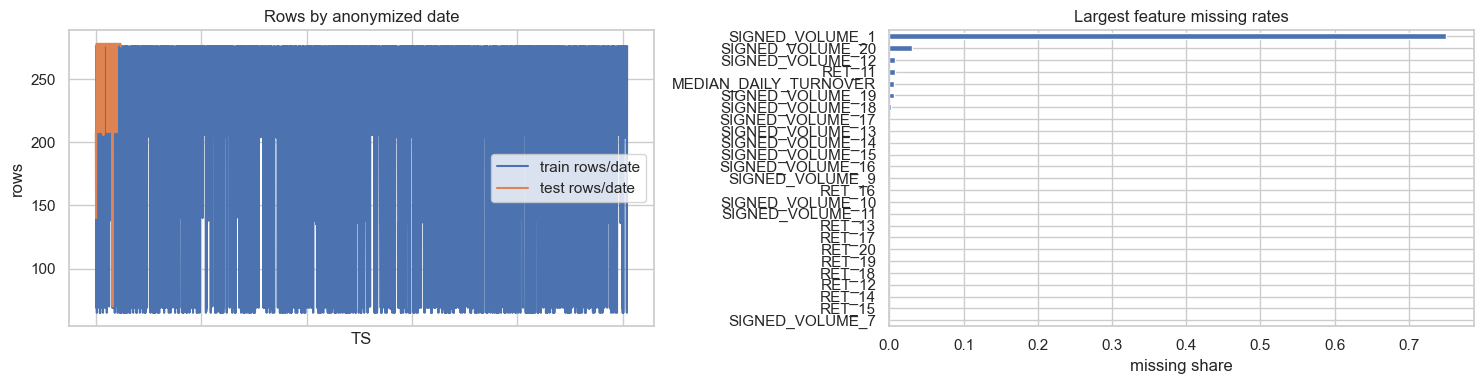

In [8]:
train_rows_by_ts = X_train.groupby("TS").size()
test_rows_by_ts = X_test.groupby("TS").size()
missing_rates = quality_report[["missing_train", "missing_test"]].max(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
train_rows_by_ts.plot(ax=axes[0], label="train rows/date")
test_rows_by_ts.plot(ax=axes[0], label="test rows/date")
axes[0].set_title("Rows by anonymized date")
axes[0].set_xlabel("TS")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", labelbottom=False)
axes[0].legend()

missing_rates.head(25).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Largest feature missing rates")
axes[1].set_xlabel("missing share")
plt.tight_layout()


## 4. Exploratory visualizations


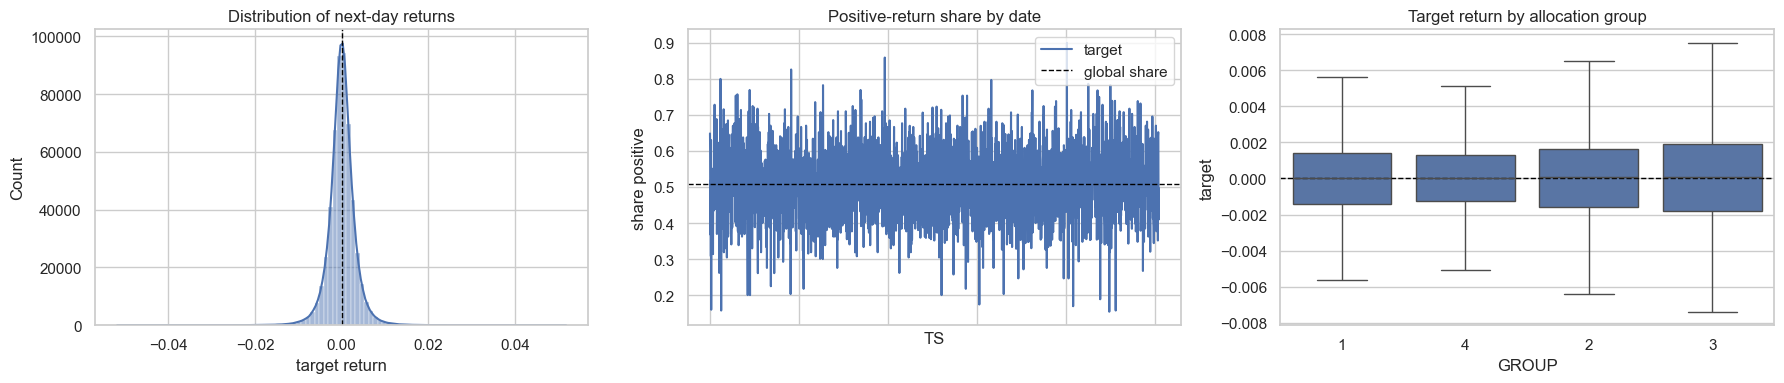

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of next-day returns")
axes[0].set_xlabel("target return")

positive_by_date = (y_train > 0).groupby(X_train["TS"]).mean()
positive_by_date.plot(ax=axes[1])
axes[1].axhline((y_train > 0).mean(), color="black", linestyle="--", linewidth=1, label="global share")
axes[1].set_title("Positive-return share by date")
axes[1].set_xlabel("TS")
axes[1].set_ylabel("share positive")
axes[1].tick_params(axis="x", labelbottom=False)
axes[1].legend()

sns.boxplot(data=pd.DataFrame({"GROUP": X_train["GROUP"].astype(str), "target": y_train}), x="GROUP", y="target", ax=axes[2], showfliers=False)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Target return by allocation group")
plt.tight_layout()


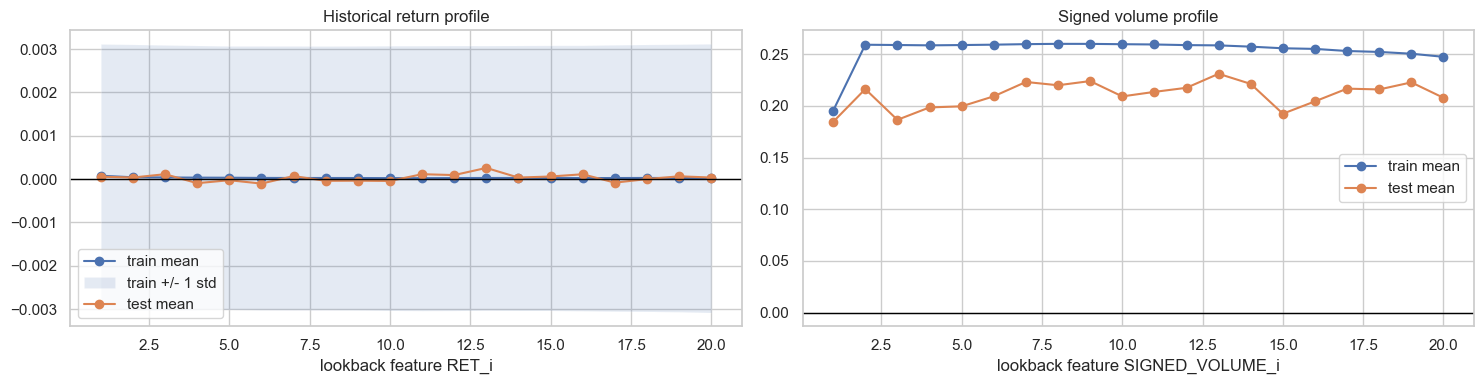

In [10]:
ret_train_mean = X_train[RET_FEATURES].mean()
ret_train_std = X_train[RET_FEATURES].std()
ret_test_mean = X_test[RET_FEATURES].mean()
volume_train_mean = X_train[SIGNED_VOLUME_FEATURES].mean()
volume_test_mean = X_test[SIGNED_VOLUME_FEATURES].mean()

x = np.arange(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(x, ret_train_mean.values, marker="o", label="train mean")
axes[0].fill_between(x, (ret_train_mean - ret_train_std).values, (ret_train_mean + ret_train_std).values, alpha=0.15, label="train +/- 1 std")
axes[0].plot(x, ret_test_mean.values, marker="o", label="test mean")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Historical return profile")
axes[0].set_xlabel("lookback feature RET_i")
axes[0].legend()

axes[1].plot(x, volume_train_mean.values, marker="o", label="train mean")
axes[1].plot(x, volume_test_mean.values, marker="o", label="test mean")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Signed volume profile")
axes[1].set_xlabel("lookback feature SIGNED_VOLUME_i")
axes[1].legend()
plt.tight_layout()


,target_mean,target_std,n_obs,positive_share
GROUP,,,,
1,8.230095e-08,0.003131,100170,0.500519
2,3.844411e-05,0.003093,134928,0.509783
3,5.022797e-05,0.003464,168913,0.509919
4,3.731320e-05,0.002527,123062,0.506005


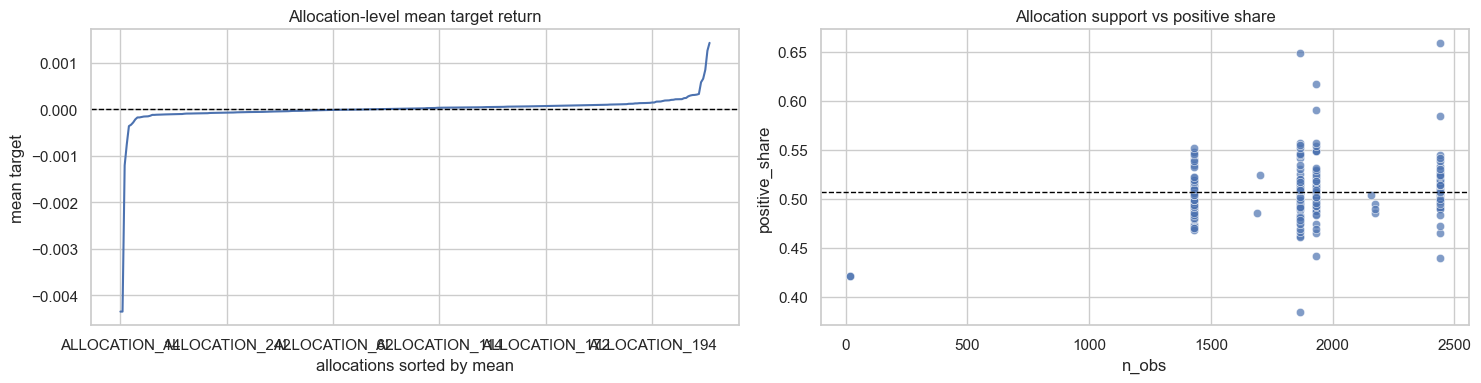

In [11]:
allocation_stats = pd.DataFrame({
    "target_mean": y_train.groupby(X_train["ALLOCATION"]).mean(),
    "target_std": y_train.groupby(X_train["ALLOCATION"]).std(),
    "n_obs": y_train.groupby(X_train["ALLOCATION"]).size(),
    "positive_share": (y_train > 0).groupby(X_train["ALLOCATION"]).mean(),
}).sort_values("target_mean")

group_stats = pd.DataFrame({
    "target_mean": y_train.groupby(X_train["GROUP"]).mean(),
    "target_std": y_train.groupby(X_train["GROUP"]).std(),
    "n_obs": y_train.groupby(X_train["GROUP"]).size(),
    "positive_share": (y_train > 0).groupby(X_train["GROUP"]).mean(),
}).sort_index()

display(group_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
allocation_stats["target_mean"].plot(ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Allocation-level mean target return")
axes[0].set_xlabel("allocations sorted by mean")
axes[0].set_ylabel("mean target")

sns.scatterplot(data=allocation_stats, x="n_obs", y="positive_share", ax=axes[1], alpha=0.7)
axes[1].axhline((y_train > 0).mean(), color="black", linestyle="--", linewidth=1)
axes[1].set_title("Allocation support vs positive share")
plt.tight_layout()


## 5. Feature engineering

The benchmark starts with raw `RET_i`, `SIGNED_VOLUME_i`, and `MEDIAN_DAILY_TURNOVER` features. The additional features below summarize the 20-day history through short-window momentum, volatility, sign balance, signed-volume imbalance, trend, and date-level cross-sectional averages. Date-level features are computed separately within train and test timestamps and use only contemporaneous challenge features, not the target.


In [12]:
def ts_number(ts: pd.Series) -> pd.Series:
    return ts.astype(str).str.extract(r"(\d+)", expand=False).astype(int)


def add_rolling_summary_features(out: pd.DataFrame, prefix: str, cols: list[str], windows=(3, 5, 10, 20)) -> pd.DataFrame:
    values = out[cols]
    for window in windows:
        selected = cols[:window]
        window_values = out[selected]
        out[f"{prefix}_mean_{window}"] = window_values.mean(axis=1)
        out[f"{prefix}_std_{window}"] = window_values.std(axis=1)
        out[f"{prefix}_min_{window}"] = window_values.min(axis=1)
        out[f"{prefix}_max_{window}"] = window_values.max(axis=1)
        out[f"{prefix}_abs_mean_{window}"] = window_values.abs().mean(axis=1)
        out[f"{prefix}_positive_share_{window}"] = (window_values > 0).mean(axis=1)
    out[f"{prefix}_last"] = values.iloc[:, 0]
    out[f"{prefix}_oldest"] = values.iloc[:, -1]
    out[f"{prefix}_last_minus_oldest"] = out[f"{prefix}_last"] - out[f"{prefix}_oldest"]
    return out


def row_trend(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    x = np.arange(len(cols), dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return df[cols].to_numpy() @ x / denom


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["TS_NUM"] = ts_number(out["TS"])

    out = add_rolling_summary_features(out, "ret", RET_FEATURES)
    out = add_rolling_summary_features(out, "signed_volume", SIGNED_VOLUME_FEATURES)

    ret = out[RET_FEATURES]
    signed_volume = out[SIGNED_VOLUME_FEATURES]

    out["ret_cum_20"] = ret.sum(axis=1)
    out["ret_volatility_20"] = ret.std(axis=1)
    out["ret_sharpe_proxy_20"] = out["ret_mean_20"] / (out["ret_std_20"].abs() + 1e-8)
    out["ret_trend_20"] = row_trend(out, RET_FEATURES)
    out["ret_drawdown_proxy_20"] = ret.cumsum(axis=1).min(axis=1)
    out["ret_runup_proxy_20"] = ret.cumsum(axis=1).max(axis=1)

    out["signed_volume_sum_20"] = signed_volume.sum(axis=1)
    out["signed_volume_abs_sum_20"] = signed_volume.abs().sum(axis=1)
    out["signed_volume_imbalance_20"] = out["signed_volume_sum_20"] / (out["signed_volume_abs_sum_20"] + 1e-8)
    out["signed_volume_trend_20"] = row_trend(out, SIGNED_VOLUME_FEATURES)

    out["turnover_log1p"] = np.log1p(out["MEDIAN_DAILY_TURNOVER"].clip(lower=0))
    out["ret_mean_5_x_turnover"] = out["ret_mean_5"] * out["turnover_log1p"]
    out["ret_volatility_20_x_turnover"] = out["ret_volatility_20"] * out["turnover_log1p"]
    out["signed_volume_imbalance_x_ret_mean_5"] = out["signed_volume_imbalance_20"] * out["ret_mean_5"]

    cross_sectional_cols = [
        "ret_mean_3", "ret_mean_5", "ret_mean_20", "ret_volatility_20",
        "signed_volume_mean_5", "signed_volume_mean_20", "signed_volume_imbalance_20",
        "turnover_log1p",
    ]
    for col in cross_sectional_cols:
        out[f"ts_mean_{col}"] = out.groupby("TS")[col].transform("mean")
        out[f"ts_centered_{col}"] = out[col] - out[f"ts_mean_{col}"]

    group_cols = ["ret_mean_5", "ret_volatility_20", "signed_volume_imbalance_20", "turnover_log1p"]
    for col in group_cols:
        out[f"group_mean_{col}"] = out.groupby(["TS", "GROUP"])[col].transform("mean")
        out[f"group_centered_{col}"] = out[col] - out[f"group_mean_{col}"]

    return out

def add_target_history_features(
    X_train_features: pd.DataFrame,
    X_test_features: pd.DataFrame,
    y: pd.Series,
    groups=("ALLOCATION", "GROUP"),
    min_history: int = 20,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_out = X_train_features.copy()
    test_out = X_test_features.copy()
    train_with_target = train_out.join(y.rename("target_return"))
    train_with_target["target_direction"] = (train_with_target["target_return"] > 0).astype(float)

    global_return_mean = y.mean()
    global_direction_mean = (y > 0).mean()

    for group_col in groups:
        date_stats = (
            train_with_target
            .groupby([group_col, "TS_NUM"], observed=True)
            .agg(
                target_return_sum=("target_return", "sum"),
                target_direction_sum=("target_direction", "sum"),
                target_count=("target_return", "size"),
            )
            .sort_index()
        )
        grouped_date_stats = date_stats.groupby(level=0, observed=True)
        count_before = grouped_date_stats["target_count"].cumsum() - date_stats["target_count"]
        return_sum_before = grouped_date_stats["target_return_sum"].cumsum() - date_stats["target_return_sum"]
        direction_sum_before = grouped_date_stats["target_direction_sum"].cumsum() - date_stats["target_direction_sum"]

        history = pd.DataFrame(index=date_stats.index)
        history["count_before"] = count_before
        history["return_mean_before"] = return_sum_before / count_before.replace(0, np.nan)
        history["direction_mean_before"] = direction_sum_before / count_before.replace(0, np.nan)

        return_feature = f"hist_{group_col.lower()}_target_mean"
        direction_feature = f"hist_{group_col.lower()}_positive_share"
        count_feature = f"hist_{group_col.lower()}_count"

        history[return_feature] = history["return_mean_before"].where(history["count_before"] >= min_history, global_return_mean)
        history[direction_feature] = history["direction_mean_before"].where(history["count_before"] >= min_history, global_direction_mean)
        history[count_feature] = history["count_before"].clip(upper=500)

        feature_lookup = history[[return_feature, direction_feature, count_feature]]
        row_key = pd.MultiIndex.from_arrays([train_out[group_col], train_out["TS_NUM"]])
        aligned_history = feature_lookup.reindex(row_key)
        aligned_history.index = train_out.index
        train_out[[return_feature, direction_feature, count_feature]] = aligned_history[[return_feature, direction_feature, count_feature]]

        train_aggregate = train_with_target.groupby(group_col).agg(
            target_return_mean=("target_return", "mean"),
            target_direction_mean=("target_direction", "mean"),
            target_count=("target_return", "size"),
        )
        test_out[return_feature] = test_out[group_col].map(train_aggregate["target_return_mean"]).fillna(global_return_mean)
        test_out[direction_feature] = test_out[group_col].map(train_aggregate["target_direction_mean"]).fillna(global_direction_mean)
        test_out[count_feature] = test_out[group_col].map(train_aggregate["target_count"]).fillna(0).clip(upper=500)

    return train_out, test_out

if USE_ENGINEERED_FEATURES:
    X_train_model = add_features(X_train)
    X_test_model = add_features(X_test)
else:
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

if USE_TARGET_HISTORY_FEATURES:
    X_train_model, X_test_model = add_target_history_features(X_train_model, X_test_model, y_train)

print("X_train_model:", X_train_model.shape)
print("X_test_model :", X_test_model.shape)


X_train_model: (527073, 143)
X_test_model : (31870, 143)


### Checkpoint plot: engineered summary features


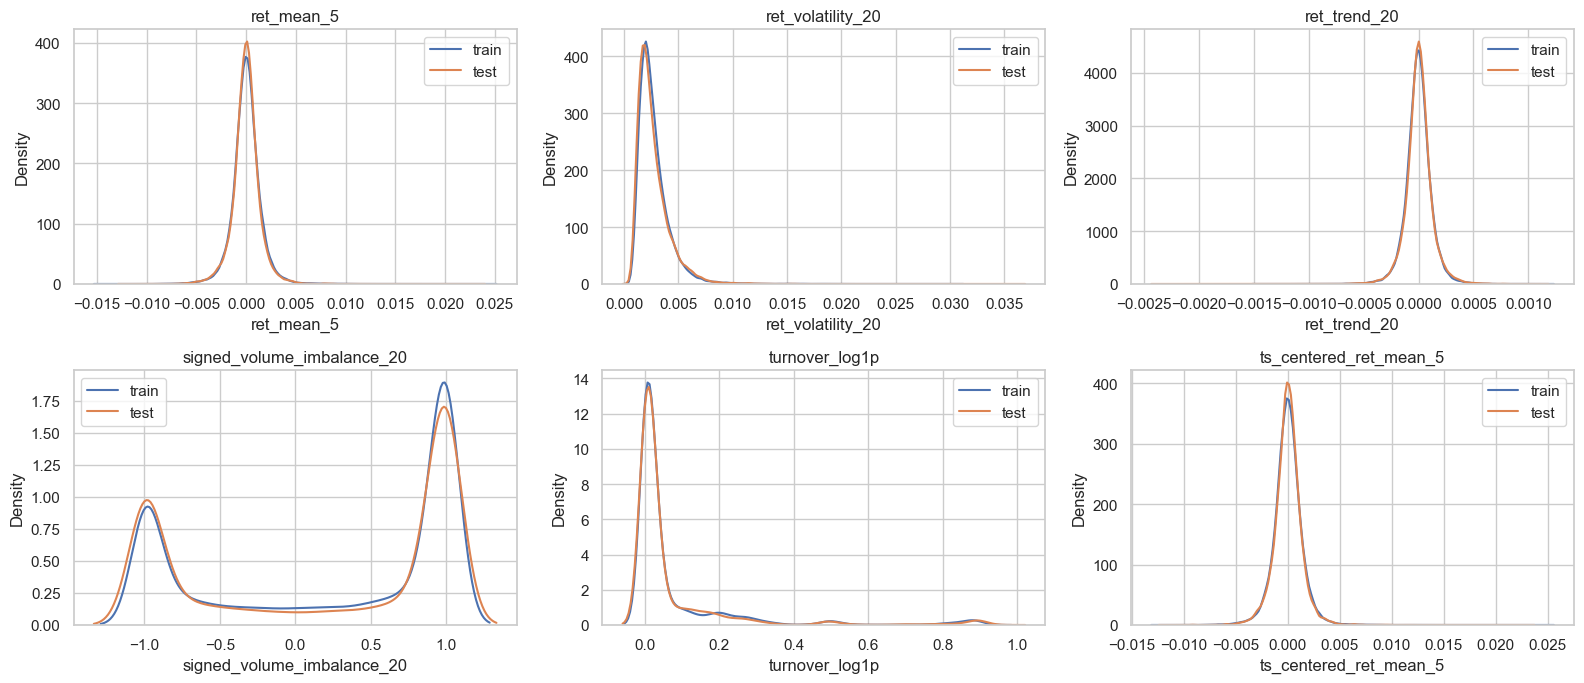

In [13]:
preview_cols = [
    "ret_mean_5", "ret_volatility_20", "ret_trend_20",
    "signed_volume_imbalance_20", "turnover_log1p", "ts_centered_ret_mean_5",
]
preview_cols = [c for c in preview_cols if c in X_train_model.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()
for ax, col in zip(axes, preview_cols):
    sns.kdeplot(X_train_model[col].replace([np.inf, -np.inf], np.nan).dropna().sample(min(50_000, len(X_train_model)), random_state=RANDOM_STATE), label="train", ax=ax)
    sns.kdeplot(X_test_model[col].replace([np.inf, -np.inf], np.nan).dropna().sample(min(30_000, len(X_test_model)), random_state=RANDOM_STATE), label="test", ax=ax)
    ax.set_title(col)
    ax.legend()
for ax in axes[len(preview_cols):]:
    ax.axis("off")
plt.tight_layout()


## 6. Feature selection diagnostics


In [14]:
all_features = list(X_train_model.columns)
non_model_features = ["TS"]
categorical_features = ["ALLOCATION", "GROUP"]

missing_rate = X_train_model[all_features].isna().mean()
nunique = X_train_model[all_features].nunique(dropna=False)
dropped_features = sorted(set(missing_rate[missing_rate > 0.98].index) | set(nunique[nunique <= 1].index) | set(non_model_features))

numeric_features = [
    c for c in X_train_model.select_dtypes(include=[np.number]).columns
    if c not in dropped_features
]
linear_features = [c for c in numeric_features if c not in ["TS_NUM"]]
lgbm_features = list(dict.fromkeys(c for c in numeric_features + categorical_features if c not in dropped_features))

print("Dropped features:", dropped_features)
print("Linear features:", len(linear_features))
print("LightGBM features:", len(lgbm_features))


Dropped features: ['TS']
Linear features: 140
LightGBM features: 142


In [15]:
corr_scores = X_train_model[linear_features].corrwith(y_train).abs().sort_values(ascending=False)
corr_table = corr_scores.head(TOP_FEATURES_FOR_REPORT).to_frame("abs_corr_with_target")
corr_table


,abs_corr_with_target
RET_1,0.084853
ret_last,0.084853
ret_last_minus_oldest,0.057223
hist_allocation_target_mean,0.046026
hist_allocation_positive_share,0.040629
ret_mean_5_x_turnover,0.037712
ret_mean_3,0.035303
ret_mean_10,0.033856
ret_runup_proxy_20,0.033396
ret_min_3,0.031777


In [16]:
mi_sample_size = min(DIAGNOSTIC_SAMPLE_SIZE, len(X_train_model))
mi_sample = X_train_model.sample(mi_sample_size, random_state=RANDOM_STATE) if len(X_train_model) > mi_sample_size else X_train_model
mi_y = y_train.loc[mi_sample.index]
mi_input = mi_sample[linear_features].replace([np.inf, -np.inf], np.nan).fillna(0)

mi_scores = mutual_info_regression(mi_input, mi_y, random_state=RANDOM_STATE)
mi_table = pd.Series(mi_scores, index=linear_features).sort_values(ascending=False).head(TOP_FEATURES_FOR_REPORT).to_frame("mutual_information")
mi_table


,mutual_information
ret_volatility_20,0.085195
ret_std_20,0.085195
ret_abs_mean_20,0.080884
ret_std_10,0.077639
ret_abs_mean_10,0.075726
ret_abs_mean_5,0.061667
ret_std_5,0.059493
ts_centered_ret_volatility_20,0.059196
ret_min_20,0.058255
ret_max_20,0.056337


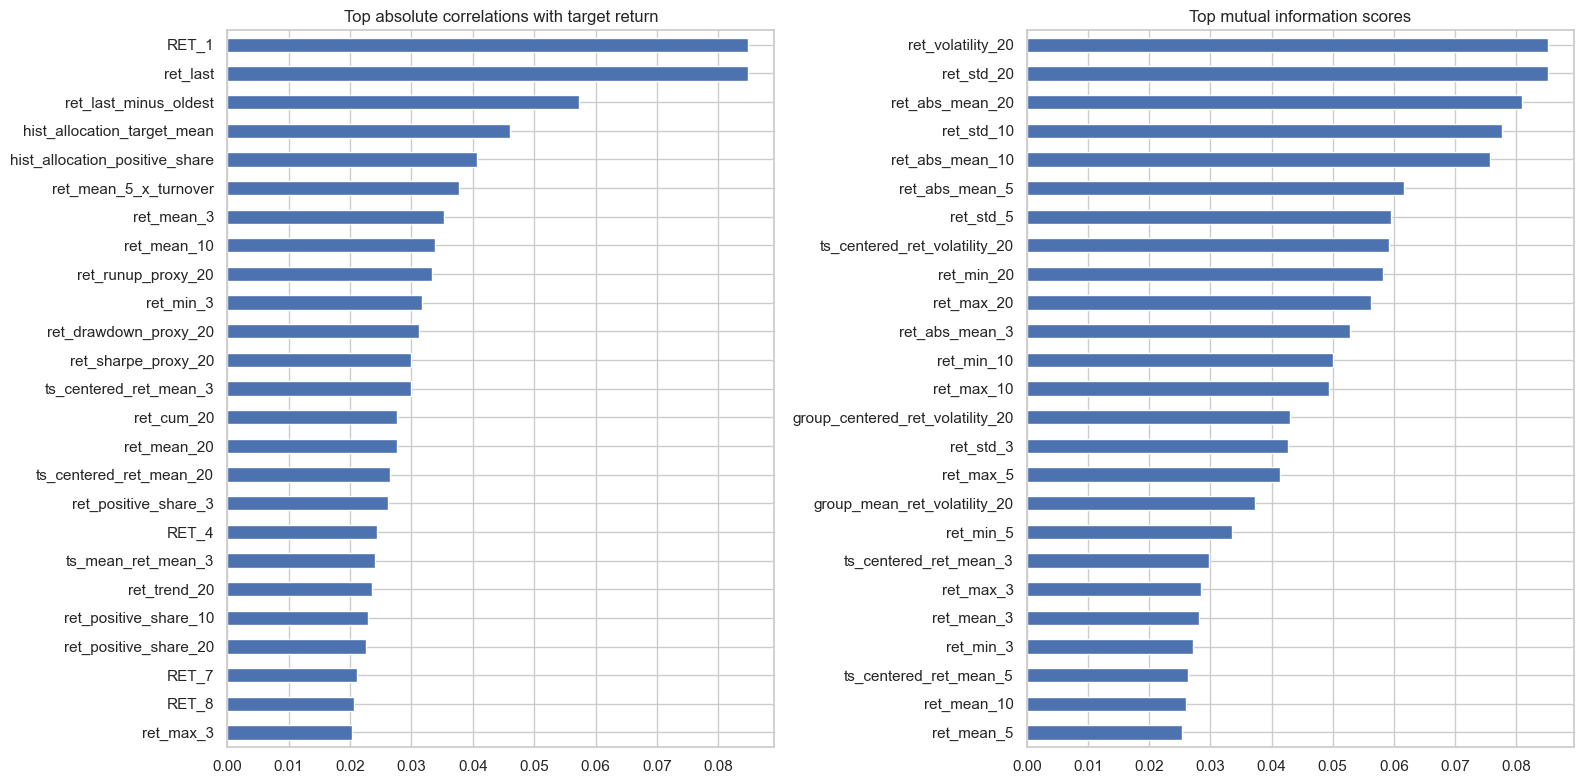

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
corr_table.sort_values("abs_corr_with_target").tail(25).plot(kind="barh", ax=axes[0], legend=False)
axes[0].set_title("Top absolute correlations with target return")
mi_table.sort_values("mutual_information").tail(25).plot(kind="barh", ax=axes[1], legend=False)
axes[1].set_title("Top mutual information scores")
plt.tight_layout()


## 7. Benchmark model: Ridge baseline plus LightGBM residuals

The CFM notebook uses a linear baseline and then lets LightGBM explain residual structure. This notebook follows the same pattern:

1. fit a regularized Ridge model on numeric features,
2. compute residual returns on the training fold,
3. fit LightGBM on residuals using numeric and categorical allocation features,
4. evaluate both return metrics and the challenge metric, sign accuracy.

The folds are chronological splits over unique `TS` values.


In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def sign_accuracy(y_true, y_pred):
    return accuracy_score((np.asarray(y_true) > 0).astype(int), (np.asarray(y_pred) > 0).astype(int))


def make_linear_model():
    return make_pipeline(
        SimpleImputer(strategy="constant", fill_value=0),
        StandardScaler(with_mean=False),
        Ridge(alpha=1.0),
    )


def make_lgbm_model(n_estimators=3000):
    return lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        n_estimators=n_estimators,
        learning_rate=0.02,
        max_depth=3,
        num_leaves=15,
        min_child_samples=120,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )


def make_lgbm_classifier(n_estimators=3000):
    return lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        n_estimators=n_estimators,
        learning_rate=0.02,
        max_depth=3,
        num_leaves=15,
        min_child_samples=120,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )


def chronological_splits_by_ts(X: pd.DataFrame, n_splits: int):
    unique_ts = pd.Series(X["TS"].unique())
    unique_ts = unique_ts.iloc[np.argsort(ts_number(unique_ts).to_numpy())].to_numpy()
    n_splits = min(n_splits, max(2, len(unique_ts) - 1))
    splitter = TimeSeriesSplit(n_splits=n_splits)
    for train_ts_idx, val_ts_idx in splitter.split(unique_ts):
        train_ts = set(unique_ts[train_ts_idx])
        val_ts = set(unique_ts[val_ts_idx])
        train_idx = X.index[X["TS"].isin(train_ts)]
        val_idx = X.index[X["TS"].isin(val_ts)]
        yield train_idx, val_idx


def as_lgbm_matrix(df: pd.DataFrame) -> pd.DataFrame:
    out = df[lgbm_features].copy()
    for col in categorical_features:
        if col in out.columns:
            out[col] = out[col].astype("category")
    return out


def probability_rank_score(values: pd.Series | np.ndarray, index=None) -> pd.Series:
    series = pd.Series(values, index=index)
    return series.rank(method="average", pct=True).clip(0, 1)


def find_best_threshold(y_true_binary: pd.Series, score: pd.Series, min_positive_share=0.35, max_positive_share=0.65):
    aligned = pd.concat([y_true_binary.rename("target"), score.rename("score")], axis=1).dropna()
    thresholds = np.unique(np.quantile(aligned["score"], np.linspace(0.05, 0.95, 181)))
    rows = []
    for threshold in thresholds:
        pred = (aligned["score"] >= threshold).astype(int)
        positive_share = pred.mean()
        if min_positive_share <= positive_share <= max_positive_share:
            rows.append({
                "threshold": threshold,
                "accuracy": accuracy_score(aligned["target"], pred),
                "positive_share": positive_share,
            })
    if not rows:
        pred = (aligned["score"] >= 0.5).astype(int)
        return 0.5, pd.DataFrame([{"threshold": 0.5, "accuracy": accuracy_score(aligned["target"], pred), "positive_share": pred.mean()}])
    table = pd.DataFrame(rows).sort_values(["accuracy", "positive_share"], ascending=[False, True]).reset_index(drop=True)
    return float(table.loc[0, "threshold"]), table


In [19]:
X_lgbm = as_lgbm_matrix(X_train_model)
y_binary = (y_train > 0).astype(int)

cv_rows = []
oof_linear_pred = pd.Series(index=X_train_model.index, dtype=float)
oof_pred = pd.Series(index=X_train_model.index, dtype=float)
oof_classifier_proba = pd.Series(index=X_train_model.index, dtype=float)
lgbm_models = []
classifier_models = []

for fold, (train_idx, val_idx) in enumerate(chronological_splits_by_ts(X_train_model, N_SPLITS), start=1):
    X_tr = X_train_model.loc[train_idx]
    X_val = X_train_model.loc[val_idx]
    y_tr = y_train.loc[train_idx]
    y_val = y_train.loc[val_idx]
    y_tr_binary = y_binary.loc[train_idx]
    y_val_binary = y_binary.loc[val_idx]

    linear_model = make_linear_model()
    linear_model.fit(X_tr[linear_features], y_tr)

    pred_tr_linear = linear_model.predict(X_tr[linear_features])
    pred_val_linear = linear_model.predict(X_val[linear_features])

    if USE_LGBM_RESIDUAL_MODEL:
        residual_tr = y_tr - pred_tr_linear
        residual_model = make_lgbm_model()
        residual_model.fit(
            X_lgbm.loc[train_idx],
            residual_tr,
            eval_set=[(X_lgbm.loc[val_idx], y_val - pred_val_linear)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)],
        )
        pred_val = pred_val_linear + residual_model.predict(X_lgbm.loc[val_idx])
        lgbm_models.append(residual_model)
        best_iteration = residual_model.best_iteration_
    else:
        pred_val = pred_val_linear
        best_iteration = None

    if USE_LGBM_CLASSIFIER:
        classifier_model = make_lgbm_classifier()
        classifier_model.fit(
            X_lgbm.loc[train_idx],
            y_tr_binary,
            eval_set=[(X_lgbm.loc[val_idx], y_val_binary)],
            eval_metric="binary_logloss",
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)],
        )
        classifier_proba_val = classifier_model.predict_proba(X_lgbm.loc[val_idx])[:, 1]
        classifier_models.append(classifier_model)
        classifier_best_iteration = classifier_model.best_iteration_
    else:
        classifier_proba_val = probability_rank_score(pred_val, index=val_idx).to_numpy()
        classifier_best_iteration = None

    oof_linear_pred.loc[val_idx] = pred_val_linear
    oof_pred.loc[val_idx] = pred_val
    oof_classifier_proba.loc[val_idx] = classifier_proba_val

    regression_rank_score = probability_rank_score(pred_val, index=val_idx)
    ensemble_score_val = 0.5 * regression_rank_score + 0.5 * pd.Series(classifier_proba_val, index=val_idx)

    cv_rows.append({
        "fold": fold,
        "train_dates": f"{X_tr['TS'].min()} to {X_tr['TS'].max()}",
        "val_dates": f"{X_val['TS'].min()} to {X_val['TS'].max()}",
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "rmse_linear": rmse(y_val, pred_val_linear),
        "rmse_final": rmse(y_val, pred_val),
        "mae_final": mean_absolute_error(y_val, pred_val),
        "r2_final": r2_score(y_val, pred_val),
        "accuracy_linear": sign_accuracy(y_val, pred_val_linear),
        "accuracy_regression_zero": sign_accuracy(y_val, pred_val),
        "accuracy_classifier_050": accuracy_score(y_val_binary, classifier_proba_val >= 0.5),
        "accuracy_ensemble_050": accuracy_score(y_val_binary, ensemble_score_val >= 0.5),
        "positive_share_val": y_val_binary.mean(),
        "positive_share_regression_zero": (pred_val > 0).mean(),
        "positive_share_classifier_050": (classifier_proba_val >= 0.5).mean(),
        "positive_share_ensemble_050": (ensemble_score_val >= 0.5).mean(),
        "best_iteration": best_iteration,
        "classifier_best_iteration": classifier_best_iteration,
    })

cv_results = pd.DataFrame(cv_rows)
cv_results


Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00324474
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.00320726
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.692648
Early stopping, best iteration is:
[72]	valid_0's binary_logloss: 0.692552
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00310707
Early stopping, best iteration is:
[14]	valid_0's rmse: 0.00308681
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.692049
Early stopping, best iteration is:
[54]	valid_0's binary_logloss: 0.691952
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.0029676
Early stopping, best iteration is:
[17]	valid_0's rmse: 0.00296565
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.691314
[200]	valid_0's binary_logloss: 0.691151
[300]	valid_0's 

,fold,train_dates,val_dates,n_train,n_val,rmse_linear,rmse_final,mae_final,r2_final,accuracy_linear,accuracy_regression_zero,accuracy_classifier_050,accuracy_ensemble_050,positive_share_val,positive_share_regression_zero,positive_share_classifier_050,positive_share_ensemble_050,best_iteration,classifier_best_iteration
0,1,DATE_0001 to DATE_0422,DATE_0423 to DATE_0842,86684,88333,0.003207,0.003207,0.002232,-0.001248,0.519364,0.519047,0.513625,0.520055,0.499621,0.450647,0.744320,0.510908,3,72
1,2,DATE_0001 to DATE_0842,DATE_0843 to DATE_1262,175017,88763,0.003087,0.003087,0.002177,-0.000342,0.514708,0.517175,0.517761,0.516409,0.509232,0.529883,0.572739,0.503814,14,54
2,3,DATE_0001 to DATE_1262,DATE_1263 to DATE_1682,263780,90030,0.002967,0.002966,0.002113,0.002520,0.517039,0.517194,0.520771,0.517394,0.500067,0.485105,0.588670,0.506009,17,222
3,4,DATE_0001 to DATE_1682,DATE_1683 to DATE_2102,353810,85843,0.003088,0.003088,0.002176,0.005571,0.520567,0.520555,0.521697,0.521836,0.505248,0.504444,0.565509,0.503838,1,357
4,5,DATE_0001 to DATE_2102,DATE_2103 to DATE_2522,439653,87420,0.003120,0.003118,0.002180,0.013443,0.523953,0.524628,0.526516,0.523450,0.517159,0.602711,0.660329,0.511119,355,357


In [20]:
cv_summary = cv_results[[
    "rmse_linear", "rmse_final", "mae_final", "r2_final",
    "accuracy_linear", "accuracy_regression_zero", "accuracy_classifier_050", "accuracy_ensemble_050",
    "positive_share_val", "positive_share_regression_zero", "positive_share_classifier_050", "positive_share_ensemble_050",
]].agg(["mean", "std"])
cv_summary


,rmse_linear,rmse_final,mae_final,r2_final,accuracy_linear,accuracy_regression_zero,accuracy_classifier_050,accuracy_ensemble_050,positive_share_val,positive_share_regression_zero,positive_share_classifier_050,positive_share_ensemble_050
mean,0.003094,0.003093,0.002176,0.003989,0.519126,0.519720,0.520074,0.519829,0.506265,0.514558,0.626313,0.507137
std,0.000086,0.000087,0.000042,0.005921,0.003511,0.003086,0.004784,0.002950,0.007264,0.057141,0.075939,0.003649


### Threshold calibration

The raw regression rule uses `return > 0`, while the classifier rule often uses probability `> 0.5`. Because the challenge metric is accuracy, we calibrate the decision threshold on out-of-fold predictions. The threshold search is constrained to avoid pathological all-long or all-short submissions.

In [21]:
valid_oof = oof_pred.notna()
y_oof_binary = y_binary.loc[valid_oof]

oof_regression_rank = probability_rank_score(oof_pred.loc[valid_oof], index=oof_pred.loc[valid_oof].index)
oof_classifier_score = oof_classifier_proba.loc[valid_oof]
oof_ensemble_score = 0.5 * oof_regression_rank + 0.5 * oof_classifier_score

best_regression_threshold, regression_threshold_table = find_best_threshold(y_oof_binary, oof_regression_rank)
best_classifier_threshold, classifier_threshold_table = find_best_threshold(y_oof_binary, oof_classifier_score)
best_ensemble_threshold, ensemble_threshold_table = find_best_threshold(y_oof_binary, oof_ensemble_score)

threshold_summary = pd.DataFrame({
    "score": ["regression_rank", "classifier_proba", "ensemble"],
    "threshold": [best_regression_threshold, best_classifier_threshold, best_ensemble_threshold],
    "accuracy": [
        regression_threshold_table.loc[0, "accuracy"],
        classifier_threshold_table.loc[0, "accuracy"],
        ensemble_threshold_table.loc[0, "accuracy"],
    ],
    "positive_share": [
        regression_threshold_table.loc[0, "positive_share"],
        classifier_threshold_table.loc[0, "positive_share"],
        ensemble_threshold_table.loc[0, "positive_share"],
    ],
}).sort_values("accuracy", ascending=False)
threshold_summary


,score,threshold,accuracy,positive_share
2,ensemble,0.472086,0.520830,0.560000
1,classifier_proba,0.503221,0.520426,0.570001
0,regression_rank,0.365001,0.520297,0.635000


### Cross-validation predictions


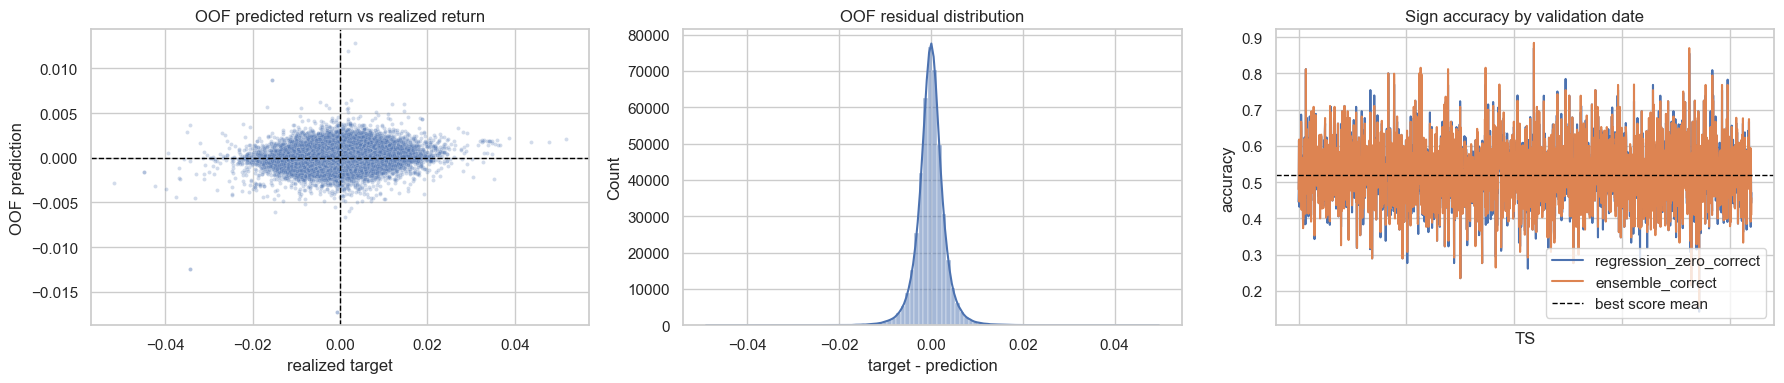

In [22]:
oof_residuals = y_train.loc[valid_oof] - oof_pred.loc[valid_oof]
oof_accuracy_by_ts = pd.DataFrame({
    "TS": X_train_model.loc[valid_oof, "TS"],
    "regression_zero_correct": ((y_train.loc[valid_oof] > 0).astype(int) == (oof_pred.loc[valid_oof] > 0).astype(int)).astype(int),
    "ensemble_correct": (y_oof_binary == (oof_ensemble_score >= best_ensemble_threshold).astype(int)).astype(int),
}).groupby("TS")[["regression_zero_correct", "ensemble_correct"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.scatterplot(x=y_train.loc[valid_oof], y=oof_pred.loc[valid_oof], s=8, alpha=0.25, ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("OOF predicted return vs realized return")
axes[0].set_xlabel("realized target")
axes[0].set_ylabel("OOF prediction")

sns.histplot(oof_residuals, bins=100, kde=True, ax=axes[1])
axes[1].set_title("OOF residual distribution")
axes[1].set_xlabel("target - prediction")

oof_accuracy_by_ts.plot(ax=axes[2])
axes[2].axhline(threshold_summary.iloc[0]["accuracy"], color="black", linestyle="--", linewidth=1, label="best score mean")
axes[2].set_title("Sign accuracy by validation date")
axes[2].set_xlabel("TS")
axes[2].set_ylabel("accuracy")
axes[2].tick_params(axis="x", labelbottom=False)
axes[2].legend()
plt.tight_layout()


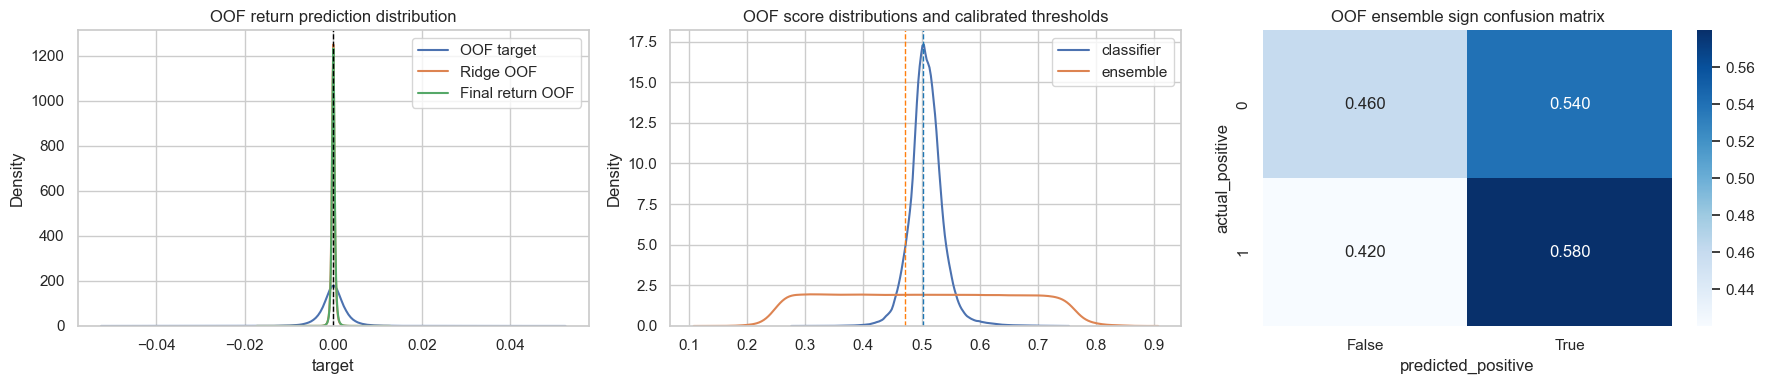

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.kdeplot(y_train.loc[valid_oof], label="OOF target", ax=axes[0])
sns.kdeplot(oof_linear_pred.loc[valid_oof], label="Ridge OOF", ax=axes[0])
sns.kdeplot(oof_pred.loc[valid_oof], label="Final return OOF", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("OOF return prediction distribution")
axes[0].legend()

sns.kdeplot(oof_classifier_score, label="classifier", ax=axes[1])
sns.kdeplot(oof_ensemble_score, label="ensemble", ax=axes[1])
axes[1].axvline(best_classifier_threshold, color="tab:blue", linestyle="--", linewidth=1)
axes[1].axvline(best_ensemble_threshold, color="tab:orange", linestyle="--", linewidth=1)
axes[1].set_title("OOF score distributions and calibrated thresholds")
axes[1].legend()

confusion = pd.crosstab(
    y_oof_binary.rename("actual_positive"),
    (oof_ensemble_score >= best_ensemble_threshold).rename("predicted_positive"),
    normalize="index",
)
sns.heatmap(confusion, annot=True, fmt=".3f", cmap="Blues", ax=axes[2])
axes[2].set_title("OOF ensemble sign confusion matrix")
plt.tight_layout()


## 8. LightGBM feature importance


In [24]:
if lgbm_models:
    importance_frames = []
    for fold, model in enumerate(lgbm_models, start=1):
        importance_frames.append(pd.DataFrame({
            "feature": model.feature_name_,
            "gain": model.booster_.feature_importance(importance_type="gain"),
            "split": model.booster_.feature_importance(importance_type="split"),
            "fold": fold,
        }))

    feature_importance = (
        pd.concat(importance_frames)
        .groupby("feature", as_index=False)[["gain", "split"]]
        .mean()
        .sort_values("gain", ascending=False)
    )
    feature_importance.to_csv(IMPORTANCE_REPORT_PATH, index=False)
    display(feature_importance.head(TOP_FEATURES_FOR_REPORT))
else:
    feature_importance = pd.DataFrame(columns=["feature", "gain", "split"])
    print("No LightGBM models were trained.")


,feature,gain,split
0,ALLOCATION,0.061428,74.0
48,group_mean_ret_mean_5,0.042037,36.0
133,ts_mean_ret_mean_20,0.026533,20.2
17,RET_4,0.024427,9.2
18,RET_5,0.023985,7.2
50,group_mean_signed_volume_imbalance_20,0.023307,12.8
52,hist_allocation_count,0.023054,6.6
3,RET_1,0.019275,23.4
140,ts_mean_turnover_log1p,0.018825,16.6
134,ts_mean_ret_mean_3,0.018129,17.4


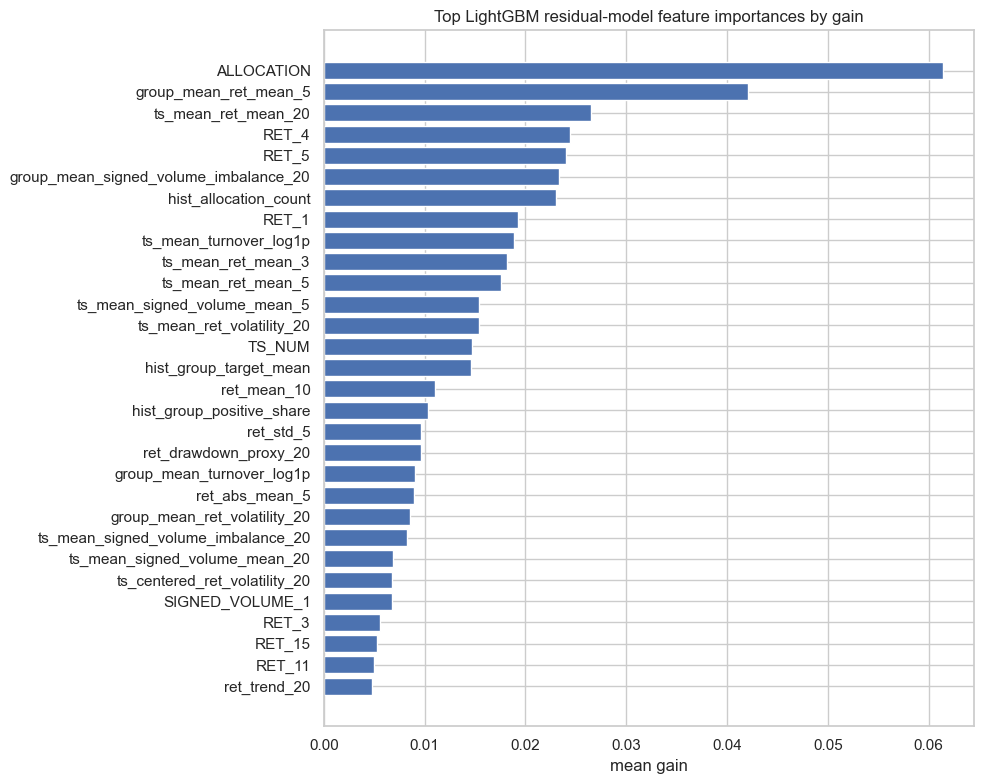

In [25]:
if not feature_importance.empty:
    plt.figure(figsize=(10, 8))
    top_importance = feature_importance.head(30).sort_values("gain")
    plt.barh(top_importance["feature"], top_importance["gain"])
    plt.title("Top LightGBM residual-model feature importances by gain")
    plt.xlabel("mean gain")
    plt.tight_layout()


## 9. Final training and submission


In [26]:
best_iterations = [m.best_iteration_ for m in lgbm_models if m.best_iteration_ is not None and m.best_iteration_ > 0]
classifier_best_iterations = [m.best_iteration_ for m in classifier_models if m.best_iteration_ is not None and m.best_iteration_ > 0]
final_n_estimators = int(np.mean(best_iterations)) if best_iterations else 800
final_classifier_n_estimators = int(np.mean(classifier_best_iterations)) if classifier_best_iterations else final_n_estimators
print("Final residual n_estimators:", final_n_estimators)
print("Final classifier n_estimators:", final_classifier_n_estimators)

X_train_lgbm_final = as_lgbm_matrix(X_train_model)
X_test_lgbm_final = as_lgbm_matrix(X_test_model)

final_linear_model = make_linear_model()
final_linear_model.fit(X_train_model[linear_features], y_train)

train_linear_pred = final_linear_model.predict(X_train_model[linear_features])
train_residual = y_train - train_linear_pred
test_linear_pred = final_linear_model.predict(X_test_model[linear_features])

final_residual_model = make_lgbm_model(n_estimators=final_n_estimators)
final_residual_model.fit(X_train_lgbm_final, train_residual)
test_residual_pred = final_residual_model.predict(X_test_lgbm_final)

final_classifier_model = make_lgbm_classifier(n_estimators=final_classifier_n_estimators)
final_classifier_model.fit(X_train_lgbm_final, y_binary)
test_classifier_proba = final_classifier_model.predict_proba(X_test_lgbm_final)[:, 1]

test_pred_raw = test_linear_pred + test_residual_pred

if CLIP_RETURN_PREDICTIONS:
    lower_clip = y_train.quantile(CLIP_LOWER_Q)
    upper_clip = y_train.quantile(CLIP_UPPER_Q)
    test_pred = np.clip(test_pred_raw, lower_clip, upper_clip)
    print(f"Clipped return predictions to [{lower_clip:.6f}, {upper_clip:.6f}]")
else:
    test_pred = test_pred_raw

test_regression_rank = probability_rank_score(test_pred, index=X_test_model.index)
test_ensemble_score = 0.5 * test_regression_rank + 0.5 * pd.Series(test_classifier_proba, index=X_test_model.index)

if USE_ENSEMBLE_SUBMISSION:
    binary_prediction = (test_ensemble_score >= best_ensemble_threshold).astype(int).to_numpy()
    decision_rule = f"ensemble_score >= {best_ensemble_threshold:.6f}"
else:
    binary_prediction = (test_pred > 0).astype(int)
    decision_rule = "predicted_return > 0"

submission = sample_submission.copy()
submission.iloc[:, 0] = binary_prediction

prediction_summary = pd.DataFrame({
    "raw_return_prediction": pd.Series(test_pred_raw).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "final_return_prediction": pd.Series(test_pred).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "classifier_probability": pd.Series(test_classifier_proba).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "ensemble_score": pd.Series(test_ensemble_score).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "binary_prediction": pd.Series(binary_prediction).describe(),
    "train_target": y_train.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
})
print("Decision rule:", decision_rule)
prediction_summary


Final residual n_estimators: 78
Final classifier n_estimators: 212
Clipped return predictions to [-0.015892, 0.016036]
Decision rule: ensemble_score >= 0.472086


,raw_return_prediction,final_return_prediction,classifier_probability,ensemble_score,binary_prediction,train_target
0.1%,-0.003788,-0.003788,0.397976,0.206367,NaN,-0.015892
1%,-0.001496,-0.001496,0.435545,0.238864,NaN,-0.008565
25%,NaN,NaN,NaN,NaN,0.000000,NaN
50%,0.000078,0.000078,0.506893,0.503628,1.000000,0.000041
75%,NaN,NaN,NaN,NaN,1.000000,NaN
99%,0.001144,0.001144,0.595142,0.780308,NaN,0.008441
99.9%,0.002651,0.002651,0.656013,0.823549,NaN,0.016036
count,31870.000000,31870.000000,31870.000000,31870.000000,31870.000000,527073.000000
max,0.011636,0.011636,0.695783,0.846966,1.000000,0.051803
mean,0.000070,0.000070,0.508050,0.504033,0.561406,0.000035


### Final prediction diagnostics


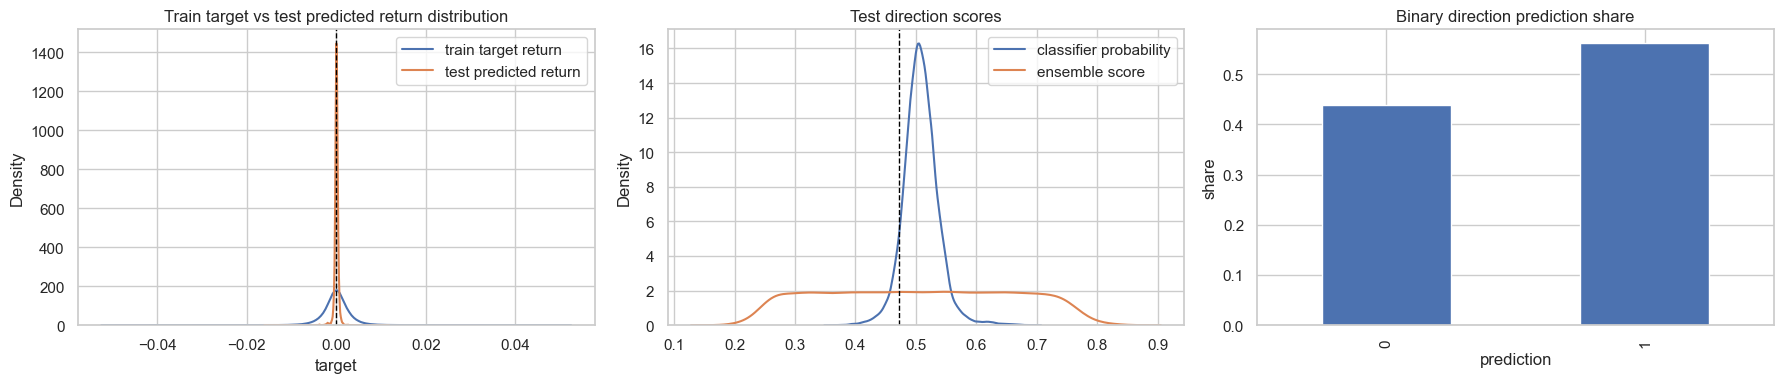

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.kdeplot(y_train, label="train target return", ax=axes[0])
sns.kdeplot(test_pred, label="test predicted return", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Train target vs test predicted return distribution")
axes[0].legend()

sns.kdeplot(test_classifier_proba, label="classifier probability", ax=axes[1])
sns.kdeplot(test_ensemble_score, label="ensemble score", ax=axes[1])
axes[1].axvline(best_ensemble_threshold, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Test direction scores")
axes[1].legend()

pd.Series(binary_prediction).value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Binary direction prediction share")
axes[2].set_xlabel("prediction")
axes[2].set_ylabel("share")
plt.tight_layout()


In [28]:
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(X_test)
assert submission.index.equals(X_test.index)
assert set(submission.iloc[:, 0].unique()).issubset({0, 1})
assert np.isfinite(submission.iloc[:, 0]).all()

submission.to_csv(SUBMISSION_PATH)
print(f"Saved submission to: {SUBMISSION_PATH}")
submission.head()


Saved submission to: /Users/anasfail/Desktop/Quant_FAIL/quant_training/QRT_dir_forecasting/data/processed/submission_qrt_lgbm_ensemble.csv


,prediction
ROW_ID,
527073,0
527074,1
527075,0
527076,0
527077,0
